In [1]:
from IPython.display import clear_output, display, Markdown, HTML
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import random
import time

import os
import dotenv
dotenv.load_dotenv()

import psycopg

from sqlalchemy import create_engine

import utils.dataset_generation as generate


Utils properly loaded


# Functions

## Production functions

In [148]:
### Functions (temporary, move to generate once ready)

## Production functions

def cluster_attributes() -> dict:
    transactions = [1, 2, 4, 5, 8, 12, 20]

    a_stats = {}  # Whale

    b_stats = {  # Babylonin lammas ## Currently 60€ per user 90d LTV, 27€ 30d
        'session_start_mu': 12.98,#13.123,
        'session_start_sigma': 0.3,#0.23
        'session_length_mu': 3600,  # 1 hour in seconds
        'session_length_sigma': 1200,  # 20 minutes in seconds
        'conversion_chance_target': {
            'a': 0,
            'b': 0,
            'c': 0,
            'd': 0,
            'e': 0,
            'f': 6,
            'g': 0
        },
        'transaction_probability': 70,
        'transaction_size': transactions,
        'transaction_size_weight': [5, 15, 15, 40, 10, 10, 5]
    }

    c_stats = {}  # Grind set

    d_stats = {  # Skin-Veeti ## Currently 29€ per user 90d LTV, 27€ 30d
        'session_start_mu':9.99, #14.016,#, Old 14 days, new 6 hours
        'session_start_sigma': 0.5,#0.1, Old for 6 hour to 12 hours, now up to 24 days
        'session_length_mu': 1200,  # 20 minutes in seconds
        'session_length_sigma': 500,
        'conversion_chance_target': {
            'a': 0,
            'b': 0,
            'c': 0,
            'd': 0,
            'e': 0,
            'f': 20,
            'g': 0
        },
        'transaction_probability': 70,
        'transaction_size': transactions,
        'transaction_size_weight': [1, 1, 5, 5, 6, 41, 1]
    }

    e_stats = {}  # Purchase curious

    f_stats = {
        # Previous cluster, reactivation chance
        'a': {},
        'b': {
            'a': 0,
            'b': 0.5,
            'c': 0,
            'd': 0,
            'e': 0,
            'f': 0,
            'g': 0
            },
        'c': {},
        'd': {
            'a': 0,
            'b': 0,
            'c': 0,
            'd': 0.1,
            'e': 0,
            'f': 0,
            'g': 0
            },
        'e': {},
        'f': {},
        'g': {
            'a': 0,
            'b': 0,
            'c': 0,
            'd': 0,
            'e': 0,
            'f': 0,
            'g': 2
        }
    }  # Churned

    g_stats = {  # Free to play
        'session_start_mu': 11.3,#11.78,#12.07,#13.123,
        'session_start_sigma': 0.2,#0.23
        'session_length_mu': 1200,  # 20 minutes in seconds
        'session_length_sigma': 500,
        'conversion_chance_target': {
            'a': 0,
            'b': 0,
            'c': 0,
            'd': 0,
            'e': 0,
            'f': 5,
            'g': 0
        }
    }


    cluster_stats = {
        'a': a_stats,
        'b': b_stats,
        'c': c_stats,
        'd': d_stats,
        'e': e_stats,
        'f': f_stats,
        'g': g_stats,
    }

    return cluster_stats


def session_start(initial_timestamp, mu, sigma, max_days=180):
    # Convert initial timestamp to pandas Timestamp
    initial_time = pd.Timestamp(initial_timestamp)

    # Generate lognormal distribution
    seconds_after = np.random.lognormal(mean=mu, sigma=sigma)#, size=num_samples)

    # Limit timescale to max_days
    max_seconds = max_days * 24 * 60 * 60  # Convert days to seconds
    if seconds_after > max_seconds:
        return None

    session_start_time = initial_time + pd.Timedelta(seconds=seconds_after)
    return session_start_time


def session_end(mean, std_dev, start_timestamp=None):
    """
    Generate a timestamp offset from the start using a bounded normal distribution.

    Parameters:
        start_timestamp (str or pd.Timestamp): Starting timestamp in 'YYYY-MM-DD HH:MM:SS' format.
        mean (float): Mean of the normal distribution (in seconds).
        std_dev (float): Standard deviation of the normal distribution (in seconds).

    Returns:
        pd.Timestamp: Generated timestamp.
    """

    # Define bounds (2 standard deviations)
    lower_bound = mean - 2 * std_dev
    upper_bound = mean + 5 * std_dev

    # Generate a valid value within bounds
    while True:
        value = np.random.normal(loc=mean, scale=std_dev)
        if lower_bound <= value <= upper_bound:
            break

    # Rescale the distribution to fit within the bounds
    scaled_value = value

    # Add the offset to the starting timestamp (if given)
    if start_timestamp is not None:
        # Convert start_timestamp to pandas Timestamp
        start_time = pd.Timestamp(start_timestamp)
        generated_timestamp = start_time + pd.Timedelta(seconds=scaled_value)
    else:
        generated_timestamp = None

    return scaled_value, generated_timestamp


def determine_session_end_cluster(session_start_cluster, cluster_stats):
    """
    Determine the session_end_cluster based on the conversion chances in cluster_stats.

    Parameters:
        session_start_cluster (str): The starting cluster for the session.
        cluster_stats (dict): Dictionary containing conversion_chance_target for clusters.

    Returns:
        str: The session_end_cluster.
    """
    # Get the conversion chance target for the session_start_cluster
    conversion_chances = cluster_stats.get(session_start_cluster, {}).get('conversion_chance_target', {})

    # Prepare the options and their probabilities
    options = list(conversion_chances.keys())
    probabilities = [conversion_chances[option] for option in options]

    # Add the default case: staying in the same cluster
    options.append(session_start_cluster)
    probabilities.append(100 - sum(probabilities))  # Remaining chance to stay

    # Normalize probabilities (in case rounding issues arise)
    probabilities = [max(0, p) for p in probabilities]  # Ensure no negative values
    total = sum(probabilities)
    probabilities = [p / total for p in probabilities]

    # Roll for the session_end_cluster
    session_end_cluster = random.choices(options, weights=probabilities, k=1)[0]

    return session_end_cluster


def calculate_reactivation(starting_timestamp, end_timestamp, reactivation_stats, churn_cluster):
    """
    Determine if reactivation occurs between two timestamps, and if so, generate a random timestamp for the reactivation.

    Parameters:
        starting_timestamp (pd.Timestamp): The starting timestamp.
        end_timestamp (pd.Timestamp): The ending timestamp.
        reactivation_chance (float): Daily reactivation chance as a percentage (e.g., 3 for 3%).

    Returns:
        pd.Timestamp or None: Reactivation timestamp if reactivation occurs, otherwise None.
    """
    if starting_timestamp is None:
        return None, None
    # Ensure timestamps are in pandas format
    starting_timestamp = pd.Timestamp(starting_timestamp)
    end_timestamp = pd.Timestamp(end_timestamp)

    # Calculate the number of days between timestamps
    days_between = (end_timestamp - starting_timestamp).days

    reactivation_chances = reactivation_stats.get(churn_cluster, {})

    # Calculate the total reactivation probability
    total_reactivation_chance = sum(reactivation_chances.values())
    days_between = (end_timestamp - starting_timestamp).days
    total_chance_over_days = 1 - (1 - total_reactivation_chance / 100) ** days_between

    # Roll to check if reactivation occurs
    if random.random() > total_chance_over_days:
        return None, None  # No reactivation

    # If reactivation occurs, pick a target cluster
    target_clusters = list(reactivation_chances.keys())
    probabilities = list(reactivation_chances.values())
    target_cluster = random.choices(target_clusters, weights=probabilities, k=1)[0]

    # Generate a random date within the range (excluding starting date)
    possible_dates = pd.date_range(start=starting_timestamp + pd.Timedelta(days=1), end=end_timestamp)
    reactivation_date = random.choice(possible_dates)

    # Generate a random time within the chosen date
    random_seconds = random.randint(0, 86400 - 1)  # Total seconds in a day
    reactivation_time = pd.Timestamp(reactivation_date) + pd.Timedelta(seconds=random_seconds)

    return reactivation_time, target_cluster


def session_length_and_actions(session_start_timestamp, user_id, session_start_cluster, running_session_number, original_cluster, session_start_action_id = 'session_start'):
    cluster_stats = cluster_attributes()

    # Generate session_end
    mu = cluster_stats[session_start_cluster]['session_length_mu']
    sigma = cluster_stats[session_start_cluster]['session_length_sigma']
    session_length, session_end_timestamp = session_end(mu, sigma, session_start_timestamp)

    session_end_cluster = determine_session_end_cluster(session_start_cluster, cluster_stats)

    # Add session row to fct_user_action
    session_id = f"{user_id}-{running_session_number}"
    row = {
        'user_id': user_id,
        'session_id': session_id,
        'running_session_number': int(running_session_number),
        'session_start': session_start_timestamp,
        'session_length': session_length,
        'session_end': session_end_timestamp,
        'original_cluster': original_cluster,
        'session_start_cluster': session_start_cluster,
        'session_end_cluster': session_end_cluster,
        'action_id': session_start_action_id,
        'action_timestamp': session_start_timestamp,
        'transaction_size': None
    }

    yield row

    # This is now basic implementation for basic functionality
    # In future generate time distribution for transaction to occur, check against end of session time,
    # if occurs then yield row and rerun with the probability now starting at the previous transaction

    # New approach
    # Transaction:
    activity = 'transaction'
    for activity_row in activity_row_generator(session_start_cluster, activity, session_start_timestamp, session_length):
        row = {
            'user_id': user_id,
            'session_id': session_id,
            'running_session_number': int(running_session_number),
            'session_start': session_start_timestamp,
            'session_length': session_length,
            'session_end': session_end_timestamp,
            'original_cluster': original_cluster,
            'session_start_cluster': session_start_cluster,
            'session_end_cluster': session_end_cluster,
            'action_id': activity_row.get('action_id'),
            'action_timestamp': activity_row.get('action_timestamp'),
            'transaction_size': activity_row.get('transaction_size')
        }
        yield row
    # /New approach
        

def activity_row_generator(session_cluster, activity_type, session_start_timestamp, session_length):
    cluster_stats = cluster_attributes()
    probability = cluster_stats.get(session_cluster).get(f'{activity_type}_probability')
    if not probability:  # Check if activity probability found in cluster attributes, otherwise break
        return

    # Transaction basic, in future do this with time distribution probability against session end in while loop 
    if activity_type == 'transaction':
        sizes = cluster_stats.get(session_cluster).get('transaction_size')
        weights = cluster_stats.get(session_cluster).get('transaction_size_weights')

        if random.random() < probability / 100:
            transaction = random.choices(sizes, weights=weights, k=1)[0]
            transaction_timestamp = session_start_timestamp + pd.Timedelta(seconds= session_length / 2)
            output_row = {
                'session_start': session_start_timestamp,
                'action_id': activity_type,
                'action_timestamp': transaction_timestamp,
                'transaction_size': transaction
            }
            yield output_row


def recursive_reactivation_function(churned):
    churned_new = []

    for row in churned:
        reactivation_time, target_cluster = calculate_reactivation(
            starting_timestamp=row['session_end'],
            end_timestamp=row['last_accepted_timestamp'],
            reactivation_stats=cluster_attributes().get('f'),
            churn_cluster=row['session_start_cluster']
            )
        if reactivation_time:
            
            session_end_timestamp = None
            last_accepted_timestamp = row['last_accepted_timestamp']
            cluster_stats = cluster_attributes()
            session_start_cluster = target_cluster
            user_id = row['user_id']
            running_session_number = row['running_session_number']
            original_cluster = row['original_cluster']

            while session_end_timestamp is None or (session_end_timestamp < last_accepted_timestamp):
                reactivation_action_id = None
                
                if session_end_timestamp is None:  # First time after reactivation
                    first_accepted_timestamp = row['session_end']
                    session_start_timestamp = reactivation_time
                    reactivation_action_id = 'reactivation'
                else:  # Subsequent sessions after initial raectivation
                    mu = cluster_stats[session_start_cluster]['session_start_mu']
                    sigma = cluster_stats[session_start_cluster]['session_start_sigma']
                    first_accepted_timestamp = session_end_timestamp  # Previous session end timestamp
                    session_start_timestamp = session_start(session_end_timestamp, mu, sigma)

                # Adjust session_start_timestamp
                session_start_timestamp = generate.adjust_timestamps(session_start_timestamp, start_bound=first_accepted_timestamp, end_bound=last_accepted_timestamp)

                # Break if session_start_timestamp is None
                if session_start_timestamp is None:
                    break
                
                ## Get user action rows
                for row in session_length_and_actions(
                            session_start_timestamp,
                            user_id, session_start_cluster,
                            running_session_number,
                            original_cluster,
                            session_start_action_id=reactivation_action_id if reactivation_action_id else 'session_start'
                        ):
                    yield row
                    last_row = row
                
                # Check if session ended in churn, if yes then pass churn parameters and break
                previous_start_cluster = last_row.get('session_start_cluster')
                previous_session_number = last_row.get('running_session_number')
                session_end_cluster = last_row.get('session_end_cluster')
                session_id = last_row.get('session_id')
                session_end_timestamp = last_row.get('session_end')
                if session_end_cluster == 'f':  # Churn
                    break  # This user will be handled separately as churned from now on

                # Update session_start_cluster for next session
                session_start_cluster = session_end_cluster  # If user cluster changed, next session will follow new cluster rules
                running_session_number += 1
            
            if session_end_cluster == 'f':  # Churn
                churned_new.append({
                    'user_id': user_id,
                    'session_id': session_id,
                    'running_session_number': previous_session_number,
                    'session_end': session_end_timestamp,
                    'original_cluster': original_cluster,
                    'session_start_cluster': previous_start_cluster,
                    'session_end_cluster': session_end_cluster,
                    'last_accepted_timestamp': last_accepted_timestamp
                })
        
    if churned_new:
        yield from recursive_reactivation_function(churned_new)












## Auxiliary functions

In [92]:
## Auxiliary functions

def find_lognormal_params(target_mode, target_range, tolerance=0.01):
    """
    Determine suitable mu and sigma for a lognormal distribution with the given mode and range.

    Parameters:
        target_mode (float): Desired mode of the distribution (in seconds).
        target_range (tuple): Desired range (in seconds) where most values should fall.
        tolerance (float): Allowed deviation from 68% probability within the range.

    Returns:
        tuple: (mu, sigma) for the lognormal distribution.
    """
    # Define range bounds
    lower_bound, upper_bound = target_range

    best_probability = 0

    # Iterate over possible sigma values
    for sigma in np.linspace(0.1, 1.0, 1000):
        # Calculate mu based on the mode equation
        mu = np.log(target_mode) + sigma**2
        
        # Calculate the CDF at the range bounds
        cdf_lower = lognorm.cdf(lower_bound, s=sigma, scale=np.exp(mu))
        cdf_upper = lognorm.cdf(upper_bound, s=sigma, scale=np.exp(mu))
        
        # Check if the cumulative probability within the range meets the tolerance

        new_probability = cdf_upper - cdf_lower

        if new_probability > best_probability:
            best_probability = new_probability

        if (new_probability) >= (1 - tolerance):
            return mu, sigma, new_probability

    raise ValueError(f"Suitable parameters not found within the given tolerance.  Best probability reached: {best_probability}")


def plot_session_start_distribution(initial_timestamp, mu, sigma, num_samples=1000, max_days=180, time_unit='seconds'):
    """
    Plot the distribution of session start times based on a lognormal distribution.

    Parameters:
        initial_timestamp (str): Initial session start time in 'YYYY-MM-DD HH:MM:SS' format.
        mu (float): Mean (log scale) for the lognormal distribution.
        sigma (float): Standard deviation (log scale) for the lognormal distribution.
        num_samples (int): Number of samples to generate for the lognormal distribution.
        max_days (int): Maximum number of days after the initial timestamp to consider.
        time_unit (str): Unit for x-axis ('seconds', 'minutes', 'hours', 'days').

    Returns:
        None: Displays the plot.
    """
    # Time unit conversion factors
    time_factors = {
        'seconds': 1,
        'minutes': 60,
        'hours': 3600,
        'days': 86400
    }

    if time_unit not in time_factors:
        raise ValueError("Invalid time_unit. Choose from 'seconds', 'minutes', 'hours', or 'days'.")

    # Convert initial timestamp to pandas Timestamp
    initial_time = pd.Timestamp(initial_timestamp)

    # Generate lognormal distribution
    seconds_after = np.random.lognormal(mean=mu, sigma=sigma, size=num_samples)

    # Limit timescale to max_days
    max_seconds = max_days * 24 * 60 * 60  # Convert days to seconds
    seconds_after = seconds_after[seconds_after <= max_seconds]

    # Scale seconds_after based on the selected time_unit
    scaled_values = seconds_after / time_factors[time_unit]

    # Create a histogram for visualization
    count, bins, _ = plt.hist(scaled_values, bins=100, density=True, alpha=0.5, color='blue', align='mid')

    # Generate PDF for the lognormal distribution
    x = np.linspace(min(bins), max(bins), 10000)
    pdf = (np.exp(-(np.log(x * time_factors[time_unit]) - mu)**2 / (2 * sigma**2)) /
           (x * time_factors[time_unit] * sigma * np.sqrt(2 * np.pi))) * time_factors[time_unit]
    plt.plot(x, pdf, linewidth=2, color='red', label='Lognormal PDF')

    # Plot settings
    plt.title('Session Start Time Distribution')
    plt.xlabel(f'Time After Initial Session ({time_unit})')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Show plot
    plt.show()

    # Optional: Print the first few session times for inspection
    print("First few session start times:")
    session_start_times = [initial_time + pd.Timedelta(seconds=sec) for sec in seconds_after]
    print(pd.Series(session_start_times).sort_values().head(10))


def plot_session_length_distribution(mu, sigma, num_samples=1000, max_seconds=86400, time_unit='minutes'):
    """
    Plot the distribution of session lengths based on a lognormal distribution.

    Parameters:
        mu (float): Mean (log scale) for the lognormal distribution.
        sigma (float): Standard deviation (log scale) for the lognormal distribution.
        num_samples (int): Number of samples to generate for the lognormal distribution.
        max_seconds (int): Maximum session length to consider (in seconds).
        time_unit (str): Unit for x-axis ('seconds', 'minutes', 'hours', 'days').

    Returns:
        None: Displays the plot.
    """
    # Time unit conversion factors
    time_factors = {
        'seconds': 1,
        'minutes': 60,
        'hours': 3600,
        'days': 86400
    }

    if time_unit not in time_factors:
        raise ValueError("Invalid time_unit. Choose from 'seconds', 'minutes', 'hours', or 'days'.")

    # Generate session lengths using the session_end function
    session_lengths = []
    for _ in range(num_samples):
        scaled_value, _ = session_end(mean=mu, std_dev=sigma)
        if scaled_value <= max_seconds:  # Ensure lengths are within max_seconds
            session_lengths.append(scaled_value)

    # Convert session lengths to the selected time unit
    scaled_values = np.array(session_lengths) / time_factors[time_unit]

    # Create a histogram for visualization
    count, bins, _ = plt.hist(scaled_values, bins=100, density=True, alpha=0.5, color='blue', align='mid')

    # Generate PDF for the bounded normal distribution
    x = np.linspace(min(bins), max(bins), 1000)
    pdf = (
        np.exp(-0.5 * ((x * time_factors[time_unit] - mu) / sigma)**2)
        / (sigma * np.sqrt(2 * np.pi))
    ) * time_factors[time_unit]
    plt.plot(x, pdf, linewidth=2, color='red', label='Bounded Normal PDF')

    # Plot settings
    plt.title('Session Length Distribution (Bounded Normal)')
    plt.xlabel(f'Session Length ({time_unit})')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Show plot
    plt.show()

    # Optional: Print the first few session lengths for inspection
    print("First few session lengths:")
    print(pd.Series(scaled_values).sort_values().head(10))


def display_scrollable(df, max_rows=999):
    pd.options.display.max_rows = 999
    pd.options.display.max_columns = 999
    html = df.to_html(max_rows=max_rows)
    html = f'<div style="max-height: 500px; overflow-y: scroll;">{html}</div>'
    display(HTML(html))
    pd.options.display.max_rows = 15
    pd.options.display.max_columns = 15


def simulate_churn_reactivation(churn_chance, reactivation_chance, sessions_per_day, num_customers, num_days=180):
    """
    Simulate churn and reactivation over a specified number of days for multiple customers.

    Parameters:
        churn_chance (float): Daily chance of a customer churning (as a percentage).
        reactivation_chance (float): Daily chance of a churned customer reactivating (as a percentage).
        sessions_per_day (float): Average number of sessions per day for active customers.
        num_customers (int): Number of simulated customers.
        num_days (int): Number of days to simulate (default is 180).

    Returns:
        pd.DataFrame: DataFrame with daily counts of active and churned users.
    """
    # Initialize results DataFrame
    results = pd.DataFrame(columns=['day', 'active_users', 'churned_users'])

    # Simulate each customer's status over time
    statuses = np.full(num_customers, 'active', dtype=object)  # Start all as active
    active_counts = []
    reactivated_counts = []
    churned_counts = []

    for day in range(1, num_days + 1):
        daily_active = 0
        daily_reactivated = 0
        daily_churned = 0

        for i in range(num_customers):
            if statuses[i] == 'active' or statuses[i] ==  'reactivated':
                # Generate sessions for the day
                num_sessions = np.random.poisson(sessions_per_day)
                for _ in range(num_sessions):
                    if np.random.random() < churn_chance / 100:
                        statuses[i] = 'churned'
                        break  # End sessions for this customer

            if statuses[i] == 'churned':
                if np.random.random() < reactivation_chance / 100:
                    statuses[i] = 'reactivated'

            # Update counts
            if statuses[i] == 'active':
                daily_active += 1
            elif statuses[i] == 'reactivated':
                daily_reactivated += 1
            else:
                daily_churned += 1

        active_counts.append(daily_active)
        reactivated_counts.append(daily_reactivated)
        churned_counts.append(daily_churned)

    # Populate results DataFrame
    results['day'] = range(1, num_days + 1)
    results['active_users'] = active_counts
    results['reactivated'] = reactivated_counts
    results['churned_users'] = churned_counts

    return results


def plot_churn_simulation(results):
    """
    Plot an area graph for the simulation results.

    Parameters:
        results (pd.DataFrame): DataFrame with daily counts of active and churned users.

    Returns:
        None: Displays the plot.
    """
    # Normalize to percentages
    total_users = results['active_users'] + results['reactivated'] + results['churned_users']
    results['active_share'] = results['active_users'] / total_users * 100
    results['reactivated_share'] = results['reactivated'] / total_users * 100
    results['churned_share'] = results['churned_users'] / total_users * 100

    # Plot the area graph
    plt.fill_between(results['day'], results['active_share'], label='Active Users', alpha=0.6)
    plt.fill_between(
        results['day'], 
        results['active_share'] + results['reactivated_share'], 
        results['active_share'], 
        label='Reactivated Users', 
        alpha=0.6
    )
    plt.fill_between(
        results['day'], 
        results['active_share'] + results['reactivated_share'] + results['churned_share'], 
        results['active_share'] + results['reactivated_share'], 
        label='Churned Users', 
        alpha=0.6
    )
    plt.title('Churn and Reactivation Simulation')
    plt.xlabel('Days')
    plt.ylabel('Percentage of Users')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_ltv_over_time(df, time_column='timestamp', value_column='total_ltv_per_user'):
    """
    Create a line graph showing 'total_ltv_per_user' over time.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        time_column (str): Name of the column containing timestamps (or timedelta).
        value_column (str): Name of the column containing the LTV values.

    Returns:
        None: Displays the plot.
    """
    # Ensure the timestamp column is in datetime format
    #df[time_column] = pd.to_datetime(df[time_column])
    # Ensure the timedelta column is in timedelta format
    df[time_column] = pd.to_timedelta(df[time_column])
    
    # Format timedelta as "X days, Y hours"
    df['timedelta_formatted'] = df[time_column].apply(
        lambda x: f"{x.days} days, {x.components.hours} hours"
    )
    
    # Convert timedelta to total seconds for uniform x-axis scaling
    df['timedelta_seconds'] = df[time_column].dt.total_seconds()

    # Sort the DataFrame by timestamp to ensure proper time progression
    df = df.sort_values(by=time_column).reset_index(drop=True)
    
    # Create a Plotly line graph
    fig = px.line(
        df,
        x='timedelta_formatted',#time_column,
        y=value_column,
        title='Total LTV Per User Over Time',
        labels={'timedelta_formatted': 'Time', value_column: 'Total LTV Per User'},
        hover_data={
#            timestamp_column: True,#: '|%Y-%m-%d %H:%M:%S',  # Format the timestamp in hover
            'timedelta_formatted': True,
            value_column: True  # Display the LTV value
        }
    )
    
    # Customize layout
    fig.update_traces(marker=dict(size=6))  # Add markers for better visibility
    fig.update_layout(
        xaxis_title='Time since install',
        yaxis_title='Total LTV Per User',
        hovermode='x unified',
        template='plotly_white'
    )
    
    # Display the plot
    fig.show()


## Database functions

In [4]:
def postgres_connection():

    username = os.getenv('USER')
    pwd = os.getenv('PWD')
    host = os.getenv('HOST')
    port = os.getenv('PORT')
    default_db = os.getenv('DEFAULT_DB')

    conn = psycopg.connect(
        host = host,
        dbname = default_db,
        user = username,
        password = pwd,
        port = port
    )
    return conn


def select_table(query: str) -> pd.DataFrame:
    conn = postgres_connection()
    with conn:
        with conn.cursor() as cur:
            cur.execute(query)
            column_headers = [desc[0] for desc in cur.description]
            df = pd.DataFrame(cur.fetchall(), columns=column_headers)
            conn.commit()
            cur.close()
    return df


def execute_sql_raw(query: str):
    conn = postgres_connection()
    with conn:
        with conn.cursor() as cur:
            cur.execute(query)
            print(f"PostgreSQL response: {cur.statusmessage}")

    conn.close()


def postgres_connection_string():
    """
    Create a connection string for SQLAlchemy to connect to PostgreSQL.
    """
    username = os.getenv("USER")
    pwd = os.getenv("PWD")
    host = os.getenv("HOST")
    port = os.getenv("PORT", 5432)
    default_db = os.getenv("DEFAULT_DB")

    return f"postgresql+psycopg://{username}:{pwd}@{host}:{port}/{default_db}"


def create_table_from_df(df, table_name):
    """
    Create a PostgreSQL table using SQLAlchemy and DataFrame structure.
    """
    connection_string = postgres_connection_string()
    engine = create_engine(connection_string)

    with engine.connect() as conn:
        df.head(0).to_sql(table_name, conn, if_exists="replace", index=False)
        print(f"Table '{table_name}' created successfully.")


def insert_df_to_table(df, table_name):
    """
    Insert rows from a pandas DataFrame into a PostgreSQL table using SQLAlchemy.
    """
    connection_string = postgres_connection_string()
    engine = create_engine(connection_string)

    with engine.connect() as conn:
        df.to_sql(table_name, conn, if_exists="append", index=False)
        print(f"Data inserted successfully into table '{table_name}'.")


In [5]:
# Deprecate these functions
def deprecate_map_dtype(value):
    """
    Map a Python value or pandas Series value to a PostgreSQL data type.
    """
    if pd.isnull(value):  # Handle NaN or None
        return "TEXT"  # Default to TEXT if the value is NaN
    elif isinstance(value, int):
        return "INTEGER"
    elif isinstance(value, float):
        return "FLOAT"
    elif isinstance(value, bool):
        return "BOOLEAN"
    elif isinstance(value, pd.Timestamp):
        return "TIMESTAMP"
    else:
        return "TEXT"


# Function to create table based on DataFrame
def deprecate_create_table_from_df(df, table_name):
    """
    Create a PostgreSQL table based on the data types of the second row of a DataFrame.

    Parameters:
        df (pd.DataFrame): The pandas DataFrame to infer schema from.
        table_name (str): The name of the PostgreSQL table to create.

    Returns:
        None
    """
    conn = postgres_connection()

    # Determine data types from the second row (or first non-NaN value in each column)
    second_row = df.iloc[1] if len(df) > 1 else df.iloc[0]
    columns = ", ".join([f"{col} {deprecate_map_dtype(second_row[col])}" for col in df.columns])

    # Create the table
    create_table_query = f"""
    DROP TABLE IF EXISTS {table_name};
    CREATE TABLE {table_name} ({columns});
    """
    
    with conn.cursor() as cur:
        cur.execute(create_table_query)
        conn.commit()
        cur.close()


# Function to insert DataFrame into PostgreSQL table
def deprecate_insert_df_to_table(df, table_name):
    """
    Insert rows from a pandas DataFrame into a PostgreSQL table.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the data to insert.
        table_name (str): The name of the PostgreSQL table to insert data into.

    Returns:
        None
    """
    conn = postgres_connection()

    # Prepare the insert query
    columns = ", ".join(df.columns)
    placeholders = ", ".join([f"%({col})s" for col in df.columns])
    insert_query = f"INSERT INTO {table_name} ({columns}) VALUES ({placeholders})"

    # Replace NaN and NaT with None to make them compatible with PostgreSQL
    df_cleaned = df.where(pd.notnull(df), None)

    with conn.cursor() as cur:
        try:
            # Iterate over rows and insert them into the table
            for _, row in df_cleaned.iterrows():
                row_dict = row.to_dict()
                
                # Convert pandas Timestamps to Python datetime
                for key, value in row_dict.items():
                    if isinstance(value, pd.Timestamp):
                        row_dict[key] = value.to_pydatetime()

                cur.execute(insert_query, row_dict)
            conn.commit()

            print(f"Data successfully inserted into table: {table_name}")
        except Exception as e:
            conn.rollback()
            print(f"Error inserting data into table: {e}")
        finally:
            cur.close()


# Data and parameter tests

## Testing attribute dict

In [36]:
#display(cluster_attributes())

session_start_cluster = 'b'
cluster_stats = cluster_attributes()
print(determine_session_end_cluster(session_start_cluster, cluster_stats))

f


In [11]:
legend = {
    'a': 'whale',
    'b': 'babylon',
    'c': 'grind set',
    'd': 'skin-veeti',
    'e': 'purchase curious',
    'f': 'churned',
    'g': 'free to play',
}

print(legend.get('c'))

grind set


In [101]:
cluster_stats = cluster_attributes()
probability = cluster_stats.get('b').get('transaction_probability')

if probability:
    proceed = True
else:
    proceed = False

sizes = cluster_stats.get('b').get('transaction_size')
weights = cluster_stats.get('b').get('transaction_size_weights')


if proceed and random.random() < probability / 100:
    transaction = random.choices(sizes, weights=weights, k=5)#[4]
    print(f'Purchased with {transaction}€')
elif proceed:
    print('no transaction this time')



Purchased with [12, 8, 1, 5, 12]€


## Database tests

In [142]:
select_query = f'''
SELECT * 
FROM fct_user_action
'''

df_c = select_table(select_query)

display_scrollable(df_c)

,user_id,session_id,session_start,session_length,session_end,original_cluster,session_start_cluster,session_end_cluster,action_id,action_timestamp,transaction_size,running_session_number


In [111]:
query = '''
CREATE TABLE postgres.public.hello_world (
hello VARCHAR(255));
INSERT INTO hello_world (hello)
VALUES
    ('world');
'''

execute_sql_raw(query=query)


PostgreSQL response: CREATE TABLE


In [113]:
query = '''
DROP TABLE IF EXISTS postgres.public.hello_world;
'''

execute_sql_raw(query=query)


PostgreSQL response: DROP TABLE


## Dataset generation test

In [3]:
cluster_shares = {
    'a': 0,
    'b': 10,
    'c': 0,
    'd': 0,
    'e': 0,
    'f': 0,
    'g': None,
}


customers_dict = generate.initial_clusters(
    cohort_size=10000,
    shares=cluster_shares
    )

#display(customers_dict)
df = generate.installation_timestamps(customers_dict, '2024-01-01', 31)
df = df.sort_values(by='timestamp', ascending=True)
#display(df)


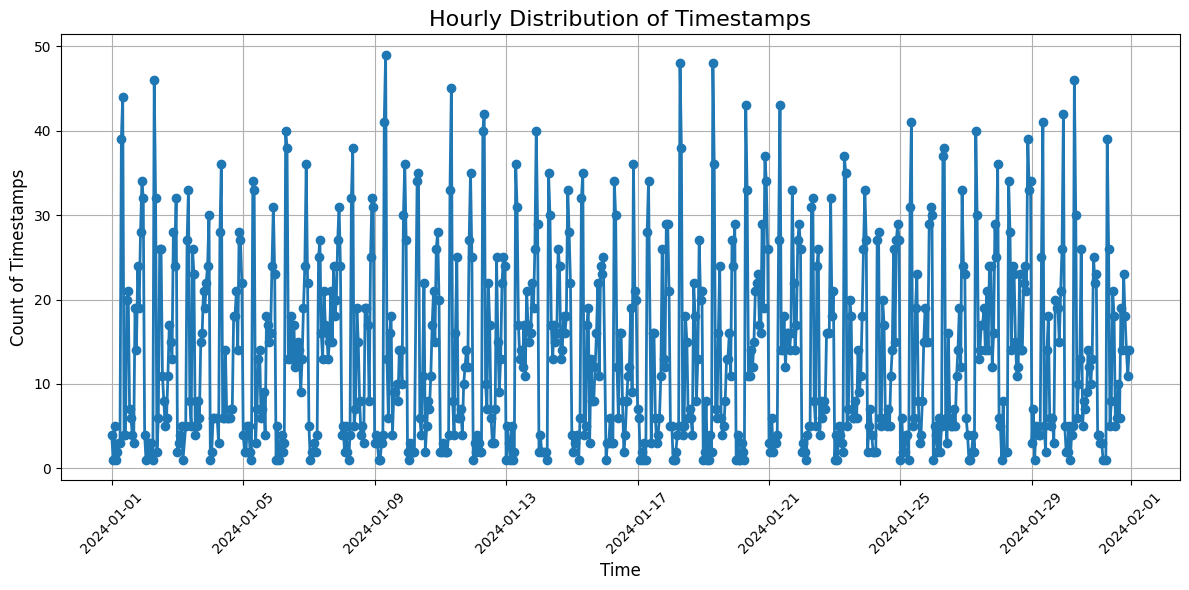

In [4]:
generate.plot_hourly_distribution(df=df)

In [5]:
generate.plotly_hourly_distribution(df=df)

,index,hour,count
0,0,2024-01-01 00:00:00,4
1,1,2024-01-01 01:00:00,1
2,2,2024-01-01 02:00:00,5
3,3,2024-01-01 03:00:00,1
4,4,2024-01-01 04:00:00,2
...,...,...,...
727,727,2024-01-31 19:00:00,23
728,728,2024-01-31 20:00:00,18
729,729,2024-01-31 21:00:00,14
730,730,2024-01-31 22:00:00,11


## Lognormal distribution test

In [105]:
## Define the target mode and range for lognormal distribution
#target_mode = 6 * 24 * 60 * 60  # 6 days in seconds
#target_range = (5 * 24 * 60 * 60, 7 * 24 * 60 * 60)  # 5 to 7 days in seconds

target_mode = 14 * 24 * 60 * 60  # 14 days hours in seconds
target_range = (3* 24 * 60 * 60, 25 * 24 * 60 * 60)  # 3 days to hours to 7 days in seconds


# Find parameters
mu, sigma, probability = find_lognormal_params(target_mode, target_range, tolerance=0.05)
print(f"Mu: {mu}, Sigma: {sigma}, probability: {probability}")


Mu: 14.015800284407405, Sigma: 0.1, probability: 0.9999999939455176


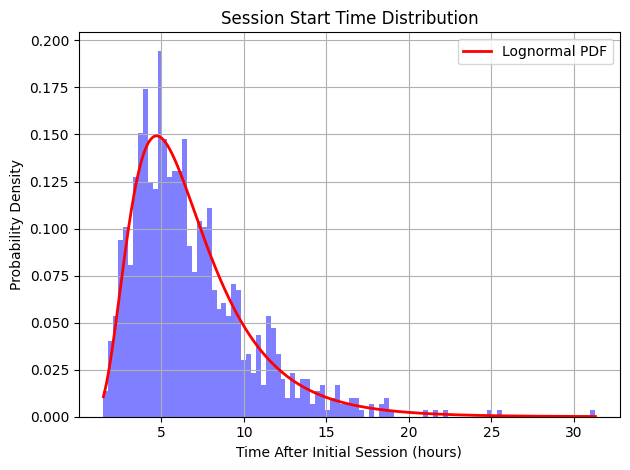

First few session start times:
36    2024-01-01 01:29:40.616720363
987   2024-01-01 01:31:37.184568091
320   2024-01-01 01:38:30.768472836
220   2024-01-01 01:46:24.429871445
947   2024-01-01 01:48:37.661787192
17    2024-01-01 01:51:01.918931730
998   2024-01-01 01:51:08.319779150
702   2024-01-01 01:54:38.755355764
510   2024-01-01 01:55:37.216698538
908   2024-01-01 01:55:47.399080394
dtype: datetime64[ns]


In [157]:
cluster_stats = cluster_attributes()

timestamp='2024-01-01 00:00:00'
mu_ = 9.99#cluster_stats.get('d').get('session_start_mu')
sigma_ = 0.5#cluster_stats.get('d').get('session_start_sigma')

plot_session_start_distribution(initial_timestamp=timestamp,
                                mu=mu_,
                                sigma=sigma_,
                                num_samples=1000,
                                time_unit='hours'
                                )

## Normal distribution tests

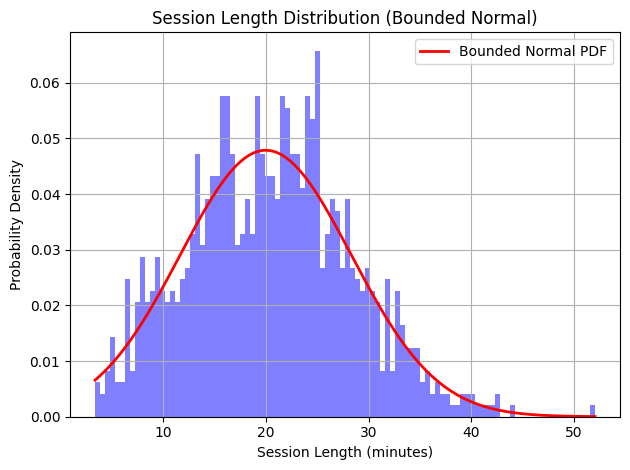

First few session lengths:
554    3.389913
824    3.612516
579    3.613541
728    3.920603
609    4.171852
263    4.408175
200    4.532730
699    4.541267
203    4.584412
704    4.927103
dtype: float64


In [62]:
cluster_stats = cluster_attributes()

mu_length_b = cluster_stats.get('b').get('session_length_mu')
sigma_length_b = cluster_stats.get('b').get('session_length_sigma')

mu_length = cluster_stats.get('d').get('session_length_mu')
sigma_length = cluster_stats.get('d').get('session_length_sigma')

plot_session_length_distribution(
    mu=mu_length,
    sigma=sigma_length
)

## Churn and reactivation tests

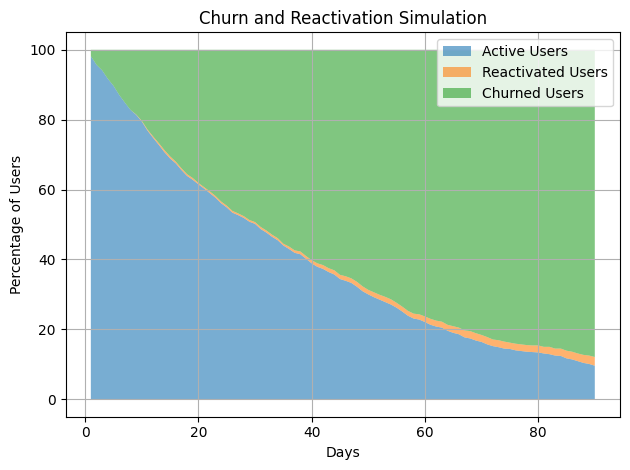

In [147]:
# Simulate the churn and reactivation process
churn_chance = 33  # 5% daily chance of churning
reactivation_chance = 0.1  # 2% daily chance of reactivation
sessions_per_day = 0.0714  # Average 1.5 sessions per day
num_customers = 1000  # Simulate 1000 customers
num_days = 90  # Simulate for 180 days

# Run simulation
results = simulate_churn_reactivation(churn_chance, reactivation_chance, sessions_per_day, num_customers, num_days)

# Visualize results
plot_churn_simulation(results)

## Session start generation tests

In [3]:
cluster_stats = cluster_attributes()

timestamp='2024-01-01 00:00:00'

# Session timestamps Babylon
mu_start_b = cluster_stats.get('b').get('session_start_mu')
sigma_start_b = cluster_stats.get('b').get('session_start_sigma')

start = session_start(
    initial_timestamp=timestamp,
    mu=mu_start_b,
    sigma=sigma_start_b
    )

mu_length_b = cluster_stats.get('b').get('session_length_mu')
sigma_length_b = cluster_stats.get('b').get('session_length_sigma')


if start is not None:
    session_length, end = session_end(
        mean=mu_length_b,
        std_dev=sigma_length_b,
        start_timestamp=start
    )
else:
    end = None

print(f'''
      B session started at {start}
      B session ended at {end}]''')


# Session timestamps
mu_start_g = cluster_stats.get('g').get('session_start_mu')
sigma_start_g = cluster_stats.get('g').get('session_start_sigma')

start = session_start(
    initial_timestamp=timestamp,
    mu=mu_start_g,
    sigma=sigma_start_g
    )

mu_length_g = cluster_stats.get('g').get('session_length_mu')
sigma_length_g = cluster_stats.get('g').get('session_length_sigma')


if start is not None:
    session_length, end = session_end(
        mean=mu_length_g,
        std_dev=sigma_length_g,
        start_timestamp=start
    )
else:
    end = None

print(f'''
      G session started at {start}
      G session ended at {end}]''')




      B session started at 2024-01-07 01:24:11.258098717
      B session ended at 2024-01-07 02:35:50.139884361]

      G session started at 2024-01-01 19:07:37.769881381
      G session ended at 2024-01-01 19:17:44.919773081]


## TODO

In [18]:
# TODO:
# [x] Create function for checking timestamp and moving it up or down based on nighttime, workday, weekend
#   [x] Revisit for not initial

# [x] Generate initial df for each customer installation time (timeframe start, timeframe length (days)
#   [x] Inside function there is even distribution random, and timestamp mover (for night, weekend, workday)
#   [x] Output: Dataframe with id, initial cluster, and first intallation timestamp

# [x] Revisit generating new user clusters - Likelihood instead of straight up deterministic number

# [] Auxiliary functions for visualizing
#   [x] Lognormal distribution
#   [x] Normal distribution
#   [o] Session cumulation and churn for cluster
#   [] Purchase revenue cumulation (absolute and per cluster participant)
#   [] Original cluster participant status share over time

# [] Dictionary where for each cluster, there is dictionary containing at least following:
#   [x] Distribution of next session start (lognormal)
#   [x] Length of next session (normal, bounded and scaled)
#   [o] Dictionary containing likelihood of changing cluster after session end
#   [] Dictionary of likelihoods of there being a certain type of purchase (Event, cosmetic, general internal currency for advancing game)
#   [] Dictionary of distributions of the purchase taking place (lognormal) for each type - generated from start and since last transaction until end
#       of session, so multiple transactions can take place for keen users
#   [] Distribution of size of each transaction (maybe just an array of sizes and set probabilities)
#   [] Distribution of activities:
#       [] Visit skin store
#       [] Visit other resource sink
#       [] Progress game proper (build resource base)
#       [] Do a match in game proper (test of skill)
#       [] Browse events

# [o] Build skeleton on how to proceed with
#   [o] checking each activity
#   [x] loop through sessions until end of timeframe
#   [o] and log activities
#   [o] and log churned into churn list
#   [o] And pass the churn list to recursive function which will check the reactivation, generate sessions, activities, and churn for reactivated,
#       and recursively pass new churn list to itself if not empty (will be empty if none reactivates, or none reactivated churns again)

# [] Now I have pandas dataframe logging for each user for timeframe fct_user_action:
#   [o] User id
#   [o] Activity Timestamp
#   [o] Activity type (install, transaction (type), activity a to e)
#   [o] Related session id (user-id-dash-running-session-id)
#   [o] Related session start timestamp
#   [o] Related session end timestamp
#   [o] OG cluster
#   [o] Related session started cluster (churned if reactivated)
#   [o] Related session ended cluster (e.g. churned or silently churned)

# Main dataset generation function

## Main

In [149]:
def main():
    
    # Generate dictionary of user clusters
    cluster_shares = {
        'a': 0,
        'b': 0,
        'c': 0,
        'd': 100,
        'e': 0,
        'f': 0,
        'g': None,
    }
    users_dict = generate.initial_clusters(
        cohort_size=1000,
        shares=cluster_shares
        )
    

    # Generate installation timestamps for all users
    df = generate.installation_timestamps(users_dict, '2024-01-01', 31)

    columns = [
        'user_id', 'session_id', 'session_start', 'session_length', 'session_end',
        'original_cluster', 'session_start_cluster', 'session_end_cluster',
        'action_id', 'action_timestamp', 'transaction_size'
    ]
    #fct_user_action = pd.DataFrame(columns=columns)

    rows = []
    churned = []
    
    cluster_stats = cluster_attributes()

    for _, user_row in df.iterrows():
        user_id = user_row['customer_id']
        original_cluster = user_row['cluster']
        install_timestamp = user_row['timestamp']

        # Add initial "install" row to fct_user_action
        rows.append({
            'user_id': user_id,
            'session_id': None,
            'session_start': None,
            'session_length': None,
            'session_end': None,
            'original_cluster': original_cluster,
            'session_start_cluster': None,
            'session_end_cluster': None,
            'action_id': 'install',
            'action_timestamp': install_timestamp,
            'transaction_size': None
        })

        # Prepare for session generation
        session_start_cluster = original_cluster
        session_end_timestamp = None
        running_session_number = 0

        last_accepted_timestamp = install_timestamp + pd.Timedelta(days=120)

        while session_end_timestamp is None or (session_end_timestamp < last_accepted_timestamp):
            # Determine session_start_timestamp
            if session_end_timestamp is None:  # First session
                if random.random() < 0.8:  # 80% chance
                    session_start_timestamp = install_timestamp + pd.Timedelta(seconds=30)
                else:  # 20% chance
                    mu = cluster_stats[session_start_cluster]['session_start_mu']
                    sigma = cluster_stats[session_start_cluster]['session_start_sigma']
                    session_start_timestamp = session_start(install_timestamp, mu, sigma)
                start_boundary = install_timestamp
            else:  # Subsequent sessions
                mu = cluster_stats[session_start_cluster]['session_start_mu']
                sigma = cluster_stats[session_start_cluster]['session_start_sigma']
                session_start_timestamp = session_start(session_end_timestamp, mu, sigma)
                start_boundary = session_end_timestamp  # Previous session end timestamp

            # Adjust session_start_timestamp
            session_start_timestamp = generate.adjust_timestamps(session_start_timestamp, start_bound=start_boundary, end_bound=last_accepted_timestamp)

            # Break if session_start_timestamp is None
            #print(f'DEBUG: {session_start_timestamp}')
            if session_start_timestamp is None:
                break
            
            ## Get user action rows
            for row in session_length_and_actions(session_start_timestamp, user_id, session_start_cluster, running_session_number, original_cluster):
                rows.append(row)
            
            # Check if session ended in churn, if yes then pass churn parameters and break
            last_row = rows[-1]
            previous_start_cluster = last_row.get('session_start_cluster')
            previous_session_number = last_row.get('running_session_number')
            session_end_cluster = last_row.get('session_end_cluster')
            session_id = last_row.get('session_id')
            session_end_timestamp = last_row.get('session_end')
            if session_end_cluster == 'f':  # Churn
                break  # This user will be handled separately as churned from now on

            # Update session_start_cluster for next session
            session_start_cluster = session_end_cluster  # If user cluster changed, next session will follow new cluster rules
            running_session_number += 1
        
        if session_end_cluster == 'f':  # Churn
            churned.append({
                'user_id': user_id,
                'session_id': session_id,
                'running_session_number': previous_session_number,
                'session_end': session_end_timestamp,
                'original_cluster': original_cluster,
                'session_start_cluster': previous_start_cluster,
                'session_end_cluster': session_end_cluster,
                'last_accepted_timestamp': last_accepted_timestamp
            })
            
    if churned:
        for row in recursive_reactivation_function(churned):
            rows.append(row)
        
    fct_user_action = pd.DataFrame(rows)
    fct_user_action['running_session_number'] = pd.to_numeric(fct_user_action['running_session_number'], errors='coerce').astype('Int64')
    df_churned = pd.DataFrame(churned)
    display(fct_user_action)
    display(df_churned)
    return fct_user_action


In [150]:
df = main()

,user_id,session_id,session_start,session_length,session_end,original_cluster,session_start_cluster,session_end_cluster,action_id,action_timestamp,transaction_size,running_session_number
0,0,None,NaT,NaN,NaT,d,None,None,install,2024-01-19 22:45:28.000000000,NaN,<NA>
1,0,0-0,2024-01-19 22:45:58.000000000,1239.504366,2024-01-19 23:06:37.504365735,d,d,d,session_start,2024-01-19 22:45:58.000000000,NaN,0
2,0,0-0,2024-01-19 22:45:58.000000000,1239.504366,2024-01-19 23:06:37.504365735,d,d,d,transaction,2024-01-19 22:56:17.752182867,12.0,0
3,0,0-1,2024-01-29 23:42:12.436380672,1638.963964,2024-01-30 00:09:31.400344563,d,d,d,session_start,2024-01-29 23:42:12.436380672,NaN,1
4,0,0-2,2024-02-12 12:49:15.457126853,1407.242732,2024-02-12 13:12:42.699858713,d,d,d,session_start,2024-02-12 12:49:15.457126853,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
8407,968,968-3,2024-04-25 20:43:24.289247331,1278.293350,2024-04-25 21:04:42.582596985,d,d,d,transaction,2024-04-25 20:54:03.435922158,5.0,3
8408,968,968-4,2024-05-05 14:53:47.422681033,1476.987705,2024-05-05 15:18:24.410385597,d,d,f,session_start,2024-05-05 14:53:47.422681033,NaN,4
8409,968,968-4,2024-05-05 14:53:47.422681033,1476.987705,2024-05-05 15:18:24.410385597,d,d,f,transaction,2024-05-05 15:06:05.916533315,8.0,4
8410,181,181-2,2024-04-19 08:39:26.264171148,1678.668610,2024-04-19 09:07:24.932781448,d,d,f,reactivation,2024-04-19 08:39:26.264171148,NaN,2


,user_id,session_id,running_session_number,session_end,original_cluster,session_start_cluster,session_end_cluster,last_accepted_timestamp
0,0,0-5,5,2024-03-25 22:59:39.159851001,d,d,f,2024-05-18 22:45:28
1,1,1-6,6,2024-03-22 12:54:38.592033909,d,d,f,2024-05-08 22:06:35
2,2,2-0,0,2024-01-18 22:16:12.935476472,d,d,f,2024-05-17 22:02:11
3,4,4-2,2,2024-01-25 07:43:58.725445594,d,d,f,2024-05-04 07:27:15
4,5,5-2,2,2024-02-15 13:02:33.375513840,d,d,f,2024-05-27 09:52:03
...,...,...,...,...,...,...,...,...
799,992,992-4,4,2024-03-17 21:12:09.204639957,d,d,f,2024-05-13 23:15:31
800,993,993-0,0,2024-01-15 00:24:36.320195108,d,d,f,2024-05-13 23:59:32
801,994,994-2,2,2024-02-11 17:16:22.885885145,d,d,f,2024-05-20 10:28:48
802,996,996-0,0,2024-01-08 23:30:59.488988138,d,d,f,2024-05-07 16:16:37


## Insert into PostgreSQL

In [151]:
table_name = "fct_user_action_test"

df_d=df

# Create the table
create_table_from_df(df_d, table_name)

# Insert the data
insert_df_to_table(df_d, table_name)

Table 'fct_user_action_test' created successfully.
Data inserted successfully into table 'fct_user_action_test'.


In [152]:
select_query = f'''
with

base as (
    SELECT * 
    FROM fct_user_action_test
),

user_install as (
    select
        user_id,
        min(action_timestamp) as install_timestamp
    from base
    where action_id = 'install'
    group by 1
)
--select * from user_install
,

transactions as (
    SELECT
        base.*,
        base.action_timestamp - user_install.install_timestamp as time_since_install
    from base
    join user_install
        on base.user_id = user_install.user_id
    where action_id = 'transaction'
)
--select * from transactions;
,

users as (
    select
        count(distinct user_id) as users_total
    from base
),

transactions_cum as (
    select
        time_since_install,
        sum(transaction_size) over (
        order by time_since_install
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) as cum_transactions
    from transactions
)
select
    transactions_cum.*,
    cum_transactions / users_total as total_ltv_per_user
from transactions_cum
join users on 1=1
order by time_since_install


'''

df_c = select_table(select_query)

display_scrollable(df_c)

,time_since_install,cum_transactions,total_ltv_per_user
0,0 days 00:02:10.273071,5.0,0.005
1,0 days 00:02:21.637784,17.0,0.017
2,0 days 00:02:22.019824,29.0,0.029
3,0 days 00:02:25.571074,37.0,0.037
4,0 days 00:02:36.730157,41.0,0.041
5,0 days 00:02:37.454187,46.0,0.046
6,0 days 00:02:38.430335,58.0,0.058
7,0 days 00:02:42.842265,70.0,0.070
8,0 days 00:02:47.298131,75.0,0.075
9,0 days 00:02:47.840624,77.0,0.077


In [94]:
# fct_user_action 10%b, 10%d
plot_ltv_over_time(df_c, time_column='time_since_install')

In [99]:
# fct_user_action1 15%b, 5%d
plot_ltv_over_time(df_c1, time_column='time_since_install')

In [104]:
# fct_user_action2 5%b, 15%d
plot_ltv_over_time(df_c2, time_column='time_since_install')

In [153]:
# Testing
plot_ltv_over_time(df_c, time_column='time_since_install')

In [21]:
data = {
    'id': [None, 1, 2],
    'name': [None, 'Alice', 'Bob'],
    'created_at': [None, pd.Timestamp('2023-01-01'), pd.Timestamp('2023-01-02')],
    'is_active': [None, True, False],
    'balance': [None, 100.5, 200.75]
}
df = pd.DataFrame(data)

display(df)
table_name = 'test_table'
# Create table
create_table_from_df(df, table_name)

# Insert data into table
insert_df_to_table(df, table_name)


,id,name,created_at,is_active,balance
0,NaN,None,NaT,None,NaN
1,1.0,Alice,2023-01-01,True,100.50
2,2.0,Bob,2023-01-02,False,200.75


Table 'test_table' created successfully.
Data inserted successfully into table 'test_table'.


In [15]:
select_query = f'''
with

base as (
    SELECT * 
    FROM fct_user_action
),

session_timestamps as (
    select
        session_start as timestamp,
        1 as users_online
    from base
    where session_start is not null

    union all

    select
        session_end as timestamp,
        -1 as users_online
    from base
    where session_end is not null
),

users_online as (
    select
        timestamp,
        sum(users_online) over (
        order by timestamp
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        )
    from session_timestamps
)
select * from users_online
'''

df_c = select_table(select_query)

display_scrollable(df_c)

,timestamp,sum
0,2024-01-01 00:41:30.000000,1
1,2024-01-01 01:17:40.811051,0
2,2024-01-01 01:34:55.000000,1
3,2024-01-01 02:23:01.000000,2
4,2024-01-01 02:39:00.000000,3
5,2024-01-01 02:46:37.287741,2
6,2024-01-01 03:23:55.435788,1
7,2024-01-01 03:57:05.903808,0
8,2024-01-01 07:02:34.000000,1
9,2024-01-01 07:03:35.000000,2


In [16]:
import plotly.express as px
import pandas as pd

def plotly_session_online(df, timestamp_column='timestamp', value_column='sum'):
    """
    Create an interactive Plotly line graph showing time-series data.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing timestamps and values.
        timestamp_column (str): Column name containing the timestamps.
        value_column (str): Column name containing the values to plot.
    
    Returns:
        None: Displays the interactive plot.
    """
    # Ensure the timestamp column is in datetime format
    df[timestamp_column] = pd.to_datetime(df[timestamp_column])
    
    # Sort the DataFrame by timestamp to ensure proper progression
    df = df.sort_values(by=timestamp_column).reset_index(drop=True)
    
    # Create a Plotly line plot
    fig = px.line(
        df,
        x=timestamp_column,
        y=value_column,
        title='Time Series Plot of Sum',
        labels={timestamp_column: 'Timestamp', value_column: 'Sum'},
        hover_data={
            timestamp_column: False,  # Exclude raw timestamp from hover
            value_column: True
        },
    )
    
    # Customize layout
    fig.update_traces(marker=dict(size=6))  # Add markers for hover points
    fig.update_layout(
        xaxis_title='Time',
        yaxis_title='Sum',
        hovermode='x unified',
        template='plotly_white'
    )
    
    # Display the plot
    fig.show()


In [18]:
#plotly_session_online(df_c, timestamp_column='timestamp', value_column='sum')

,time_since_install,cum_transactions,total_ltv_per_user
0,0 days 00:02:14.603856,12.0,0.0012
1,0 days 00:02:19.452899,14.0,0.0014
2,0 days 00:02:25.064224,26.0,0.0026
3,0 days 00:02:35.100600,27.0,0.0027
4,0 days 00:02:39.291358,31.0,0.0031
5,0 days 00:02:41.392836,33.0,0.0033
6,0 days 00:02:54.689096,37.0,0.0037
7,0 days 00:03:01.241495,57.0,0.0057
8,0 days 00:03:07.024329,65.0,0.0065
9,0 days 00:03:10.292456,85.0,0.0085


# Testing syntax

In [ ]:
print(cluster_attributes().get('f'))
listicle = []

if not listicle:
    print('Empty caught')
else:
    print('Empty not caught')

if listicle:
    print(listicle)

listicle.append({
    'user_id': 1,
    'session_id': 2,
})

if not listicle:
    print('Not handling empty list capture very well')
else:
    print('Success in handling non-empty list')

if listicle:
    print('Handling catching non-empty list')



In [23]:
#print(random.choice([1,2,3,4,5,6]))

def recursive():
    die_roll = random.choice([1, 2, 3, 4, 5, 6])
    yield die_roll
    if die_roll != 6:
        time.sleep(1)
        yield from recursive()

x = recursive()

for z in x:
    if z != 6:
        print(f'Rolled {z}, rolling again')
    else:
        print(f'Rolled {z}, no more rolling')

Rolled 4, rolling again
Rolled 1, rolling again
Rolled 6, no more rolling


In [55]:
def recursive_with_argument(numbers):
    die_roll = random.choice([1, 2, 3, 4, 5, 6])
    if die_roll in numbers:
        numbers.remove(die_roll)
    yield die_roll, numbers
    if numbers != []:
        time.sleep(1)
        yield from recursive_with_argument(numbers)

numbers_list = [1, 2, 3, 4, 5, 6]

print(f'Starting with list {numbers_list}')
time.sleep(1)
for roll, list in recursive_with_argument(numbers_list):
    if list != []:
        print(f'Rolled {roll}, list now {list}')
    else:
        print(f'Rolled {roll}, list now empty')

Starting with list [1, 2, 3, 4, 5, 6]
Rolled 4, list now [1, 2, 3, 5, 6]
Rolled 3, list now [1, 2, 5, 6]
Rolled 2, list now [1, 5, 6]
Rolled 4, list now [1, 5, 6]
Rolled 6, list now [1, 5]
Rolled 5, list now [1]
Rolled 5, list now [1]
Rolled 4, list now [1]
Rolled 5, list now [1]
Rolled 6, list now [1]
Rolled 2, list now [1]
Rolled 5, list now [1]
Rolled 6, list now [1]
Rolled 6, list now [1]
Rolled 6, list now [1]
Rolled 3, list now [1]
Rolled 4, list now [1]
Rolled 6, list now [1]
Rolled 5, list now [1]
Rolled 3, list now [1]
Rolled 4, list now [1]
Rolled 1, list now empty
